In [53]:
words = open('names.txt', 'r').read().splitlines()

In [54]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [55]:
len(words)

32033

In [56]:
b = {}
for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1

In [57]:
sorted(b.items(), key = lambda kv: -kv[1])

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [58]:
import torch

In [83]:
N = torch.zeros((27, 27), dtype=torch.int32)

chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [84]:
for w in words:
  chs = ['.'] + list(w) + ['.'] # we replaced special chars with . as special char
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    N[ix1, ix2] += 1

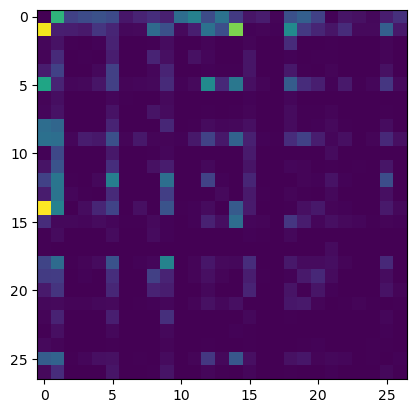

In [85]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.imshow(N)

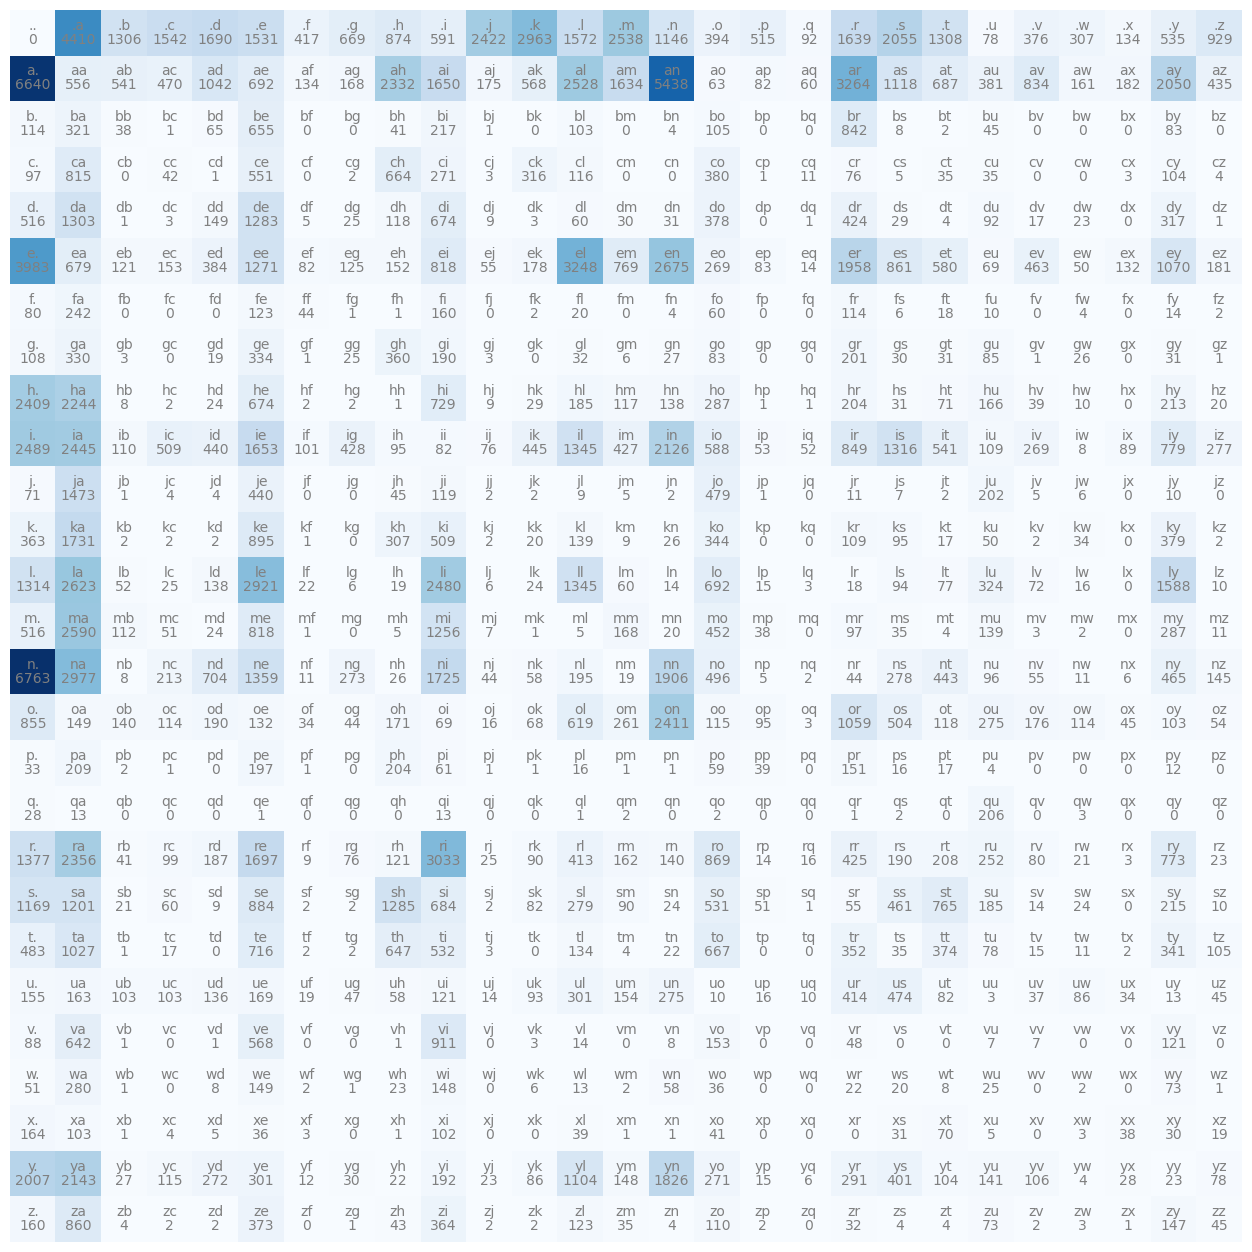

In [86]:
plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

In [87]:
N[0] #first char

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

In [88]:
p = N[0].float()
p = p / p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [89]:
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
itos[ix]

'c'

In [90]:
g = torch.Generator().manual_seed(2147483647)
p = torch.rand(3, generator = g)
p = p/p.sum()
p

tensor([0.6064, 0.3033, 0.0903])

In [91]:
torch.multinomial(p, num_samples=20, replacement=True, generator=g)

tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1])

In [92]:
g = torch.Generator().manual_seed(2147483647)

out = []
ix = 0
while True:
    p = N[ix].float()
    p = p/p.sum()
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
        break

In [98]:
P = N.float()
for i in range(27):
    sum = 0
    for j in range(27):
        sum = sum + N[i][j].item()
    for j in range(27):
        P[i][j] = N[i][j].item() / sum


g = torch.Generator().manual_seed(2147483647)

out = []
ix = 0
while True:
    p = P[ix]
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
        break
out

['c', 'e', 'x', 'z', 'e', '.']

In [103]:
P = N.float()
#P.sum(1, keepdim=True).shape # sum across the row
P = P /P.sum(1, keepdim=True) #Broadcasting - https://docs.pytorch.org/docs/2.13/notes/broadcasting.html, broadcasting goes from right to left

g = torch.Generator().manual_seed(2147483647)

out = []
ix = 0
while True:
    p = P[ix]
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
        break
out

['c', 'e', 'x', 'z', 'e', '.']

In [106]:
P = N.float()
P /= P.sum(1, keepdim=True) #emplace operation, nit create new tensor, save memory

g = torch.Generator().manual_seed(2147483647)

for i in range(5):
    out = []
    ix = 0
    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.


In [110]:
for w in words[:3]:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    prob = P[ix1, ix2]
    print(f'{ch1}{ch2}: {prob: .4f}')

.e:  0.0478
em:  0.0377
mm:  0.0253
ma:  0.3899
a.:  0.1960
.o:  0.0123
ol:  0.0780
li:  0.1777
iv:  0.0152
vi:  0.3541
ia:  0.1381
a.:  0.1960
.a:  0.1377
av:  0.0246
va:  0.2495
a.:  0.1960


Maximum Likelihood Estimation (MLE) is a statistical method used to determine the parameters of a probability distribution that best describe a given set of observed data. It works by finding the parameter values that maximize the likelihood function, making the observed data the most probable outcome. [1, 2, 3, 4]  
The Core Concept 
In MLE, you start with a dataset and an assumed probability distribution (like a Normal or Poisson distribution) that models your data. The goal is to estimate the unknown parameters, such as the mean μ and standard deviation σ. [2, 4, 5]  
The method operates on the following steps: 

1. Define the Likelihood Function (L): Assuming the data points are independent and identically distributed (IID), the likelihood function is the product of the individual probabilities (or probability densities) of observing each data point. </br>
2. $L(\theta) = \prod_{i=1}^{n} f(x_i; \theta)$ </br>
3. Here, θ represents the parameters to be estimated, and $x_i$ represents your observed data. </br>
4. **Log-Likelihood**: Multiplying many probabilities together often results in extremely small numbers that can cause numerical underflow in computers. To avoid this, statisticians convert the product into a sum by taking the natural logarithm, creating the log-likelihood function ($\ln L$): </br>
5. $\ln L(\theta) = \sum_{i=1}^{n} \ln f(x_i; \theta)$ </br>
6. Maximization: The parameters θ that maximize the log-likelihood function are found using calculus—by taking the partial derivatives with respect to the parameters, setting them to zero, and solving. [5]  </br>

Example: Normal Distribution 
If you have a dataset of continuous observations that follow a normal distribution, MLE provides a mathematically rigorous way to find the optimal mean (μ̂) and variance (σ̂²). [5, 11]  
When you maximize the log-likelihood function for a normal distribution, the maximum likelihood estimates match the intuitive sample statistics: 

• The maximum likelihood estimate for the mean is simply the sample mean: $\hat{\mu} = \frac{1}{n} \sum_{i=1}^{n} x_i$ 
• The maximum likelihood estimate for the variance is: $\hat{\sigma}^2 = \frac{1}{n} \sum_{i=1}^{n} (x_i - \hat{\mu})^2$ [5, 12]  

Why MLE is Important </br>
MLE is foundational in statistics and machine learning because it reframes parameter estimation as an optimization problem. It offers several desirable properties: </br>

• Consistency: As the sample size grows infinitely large, the parameter estimates converge on the true population parameters. </br>
• Asymptotic Normality: With large datasets, the distribution of the parameter estimates themselves approaches a normal distribution. </br>
• Efficiency: MLE estimates typically have the smallest possible variance compared to other unbiased estimation methods. [15, 16]  </br>

[1] https://en.wikipedia.org/wiki/Maximum_likelihood_estimation
[2] https://www.geeksforgeeks.org/machine-learning/probability-density-estimation-maximum-likelihood-estimation/
[3] https://www.cqf.com/blog/quant-finance-101/what-is-maximum-likelihood-estimation
[4] https://brilliant.org/wiki/maximum-likelihood-estimation-mle/
[5] https://www.youtube.com/watch?v=x5GOUgCTkjM
[6] https://www.probabilitycourse.com/chapter8/8_2_3_max_likelihood_estimation.php
[7] https://web.stanford.edu/class/archive/cs/cs109/cs109.1206/lectureNotes/LN20_parameters_mle.pdf
[8] https://reliability.readthedocs.io/en/latest/How%20does%20Maximum%20Likelihood%20Estimation%20work.html
[9] https://haddonm.github.io/URMQMF/model-parameter-estimation.html
[10] https://www.sciencedirect.com/science/article/pii/S016794732600006X
[11] https://online.stat.psu.edu/stat415/lesson/1/1.2
[12] https://www.statlect.com/fundamentals-of-statistics/normal-distribution-maximum-likelihood
[13] https://www.hyperbots.com/glossary/maximum-likelihood-estimation-mle
[14] https://www.youtube.com/watch?v=rCdxlN6Ph14
[15] https://www.youtube.com/watch?v=YevSE6bRhTo
[16] https://www.sciencedirect.com/science/article/pii/S0022460X24005261


In [116]:
# GOAL: maximize likelihood of the data w.r.t. model parameters (statistical modeling)
# equivalent to maximizing the log likelihood (because log is monotonic)
# equivalent to minimizing the negative log likelihood
# equivalent to minimizing the average negative log likelihood

# log(a*b*c) = log(a) + log(b) + log(c)

In [118]:
log_likelihood = 0.0
n = 0
for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    prob = P[ix1, ix2]
    logprob = torch.log(prob)
    log_likelihood += logprob
    n+=1
    # print(f'{ch1}{ch2}: {prob: .4f} {logprob: .4f}')

print(f'{log_likelihood=}')
nll = - log_likelihood
print(f'{nll=}')
print(f'{nll/n}')

log_likelihood=tensor(-559891.7500)
nll=tensor(559891.7500)
2.454094171524048


In [123]:
log_likelihood = 0.0
n = 0
for w in ['ribhuuuuu']:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    prob = P[ix1, ix2]
    logprob = torch.log(prob)
    log_likelihood += logprob
    n+=1
    print(f'{ch1}{ch2}: {prob: .4f} {logprob: .4f}')

print(f'{log_likelihood=}')
nll = - log_likelihood
print(f'{nll=}')
print(f'{nll/n}')

.r:  0.0512 -2.9727
ri:  0.2388 -1.4320
ib:  0.0062 -5.0809
bh:  0.0155 -4.1669
hu:  0.0218 -3.8260
uu:  0.0010 -6.9518
uu:  0.0010 -6.9518
uu:  0.0010 -6.9518
uu:  0.0010 -6.9518
u.:  0.0494 -3.0070
log_likelihood=tensor(-48.2925)
nll=tensor(48.2925)
4.829254627227783


In [128]:
P = (N+1).float()

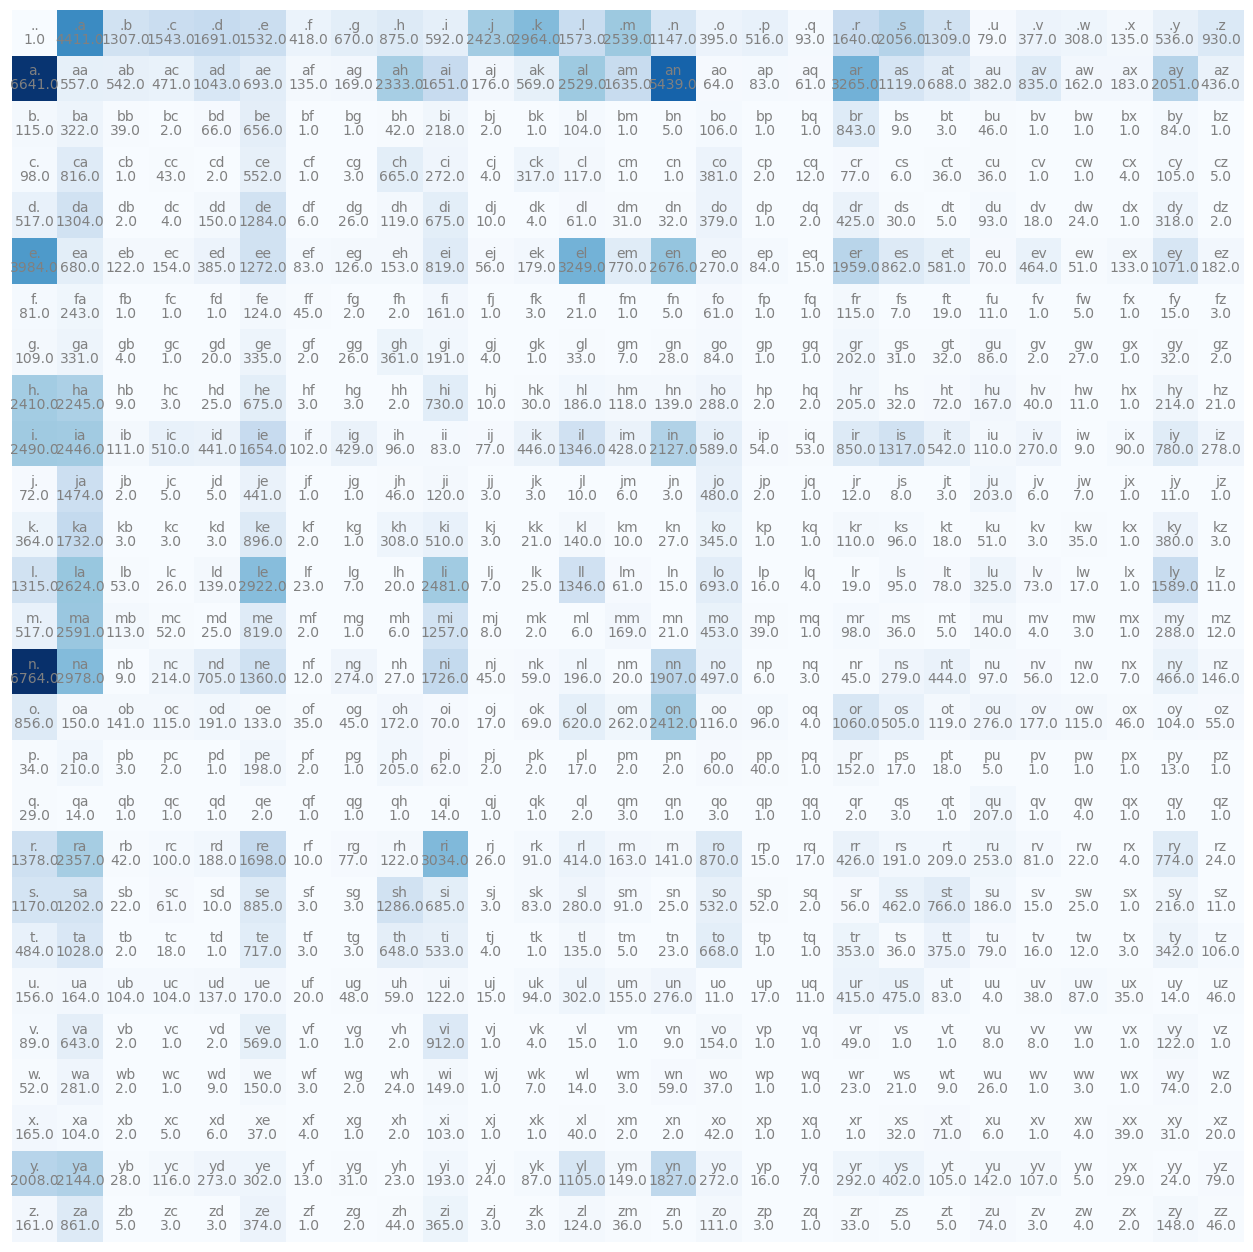

In [129]:
plt.figure(figsize=(16,16))
plt.imshow(P, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, P[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

In [130]:
P /= P.sum(1, keepdim=True)
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
    out = []
    ix = 0
    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.


In [136]:
# create the training set
xs, ys = [], []

for w in words[:1]:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    print(ch1, ch2)
    xs.append(ix1)
    ys.append(ix2)

xs = torch.tensor(xs) #use lowercase t tensor when possible, it preserves data type
ys = torch.tensor(ys)

. e
e m
m m
m a
a .


In [137]:
xs

tensor([ 0,  5, 13, 13,  1])

In [138]:
ys

tensor([ 5, 13, 13,  1,  0])

In [141]:
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes=27).float() # floats can feed into neurons
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

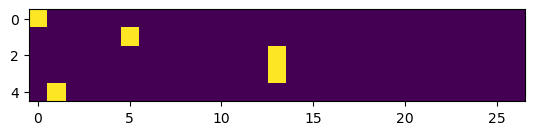

In [142]:
plt.imshow(xenc)

In [145]:
W = torch.randn((27, 27))
xenc @ W

tensor([[-1.3414,  0.1475, -1.2126, -0.5744,  1.9244,  1.4550, -0.5366, -0.3528,
         -0.6664,  1.0946,  0.1471,  0.4986, -0.6368,  1.0027,  0.1326, -1.4331,
          0.1033, -1.5465,  1.0745,  0.8455,  0.5085, -1.6755,  0.5235, -0.9267,
          0.3868, -1.0407,  0.7557],
        [ 0.4000, -0.8426, -0.1737,  0.8882, -0.1742,  2.1746, -0.5110, -0.5930,
          2.3827, -1.0814,  0.9839, -1.2297, -1.1015, -0.9143, -0.1912, -0.6914,
         -0.6007, -0.7830,  1.0207,  1.8069,  0.5366, -1.8118,  0.6093, -1.3687,
         -0.0289,  0.8445, -1.3639],
        [-0.6403,  0.8028,  0.3084,  1.2480, -0.2273,  1.7888, -0.0447, -2.3287,
         -0.1414, -0.5956,  0.0949, -0.3301,  0.2234, -1.5262,  0.1337,  0.1699,
         -2.5451, -0.3614, -0.1626, -0.4049, -0.5160,  0.2510, -1.4235, -0.9840,
          0.5621, -0.4966,  0.4728],
        [-0.6403,  0.8028,  0.3084,  1.2480, -0.2273,  1.7888, -0.0447, -2.3287,
         -0.1414, -0.5956,  0.0949, -0.3301,  0.2234, -1.5262,  0.1337,  0.1699

In [148]:
logits = xenc @ W # log-counts
counts = logits = logits.exp()
probs = counts / counts.sum(1, keepdims=True)
probs

tensor([[0.0065, 0.0289, 0.0074, 0.0140, 0.1708, 0.1068, 0.0146, 0.0175, 0.0128,
         0.0745, 0.0289, 0.0410, 0.0132, 0.0679, 0.0285, 0.0059, 0.0276, 0.0053,
         0.0730, 0.0581, 0.0415, 0.0047, 0.0421, 0.0099, 0.0367, 0.0088, 0.0531],
        [0.0301, 0.0087, 0.0170, 0.0490, 0.0169, 0.1775, 0.0121, 0.0111, 0.2185,
         0.0068, 0.0540, 0.0059, 0.0067, 0.0081, 0.0167, 0.0101, 0.0111, 0.0092,
         0.0560, 0.1229, 0.0345, 0.0033, 0.0371, 0.0051, 0.0196, 0.0469, 0.0052],
        [0.0169, 0.0715, 0.0436, 0.1116, 0.0255, 0.1916, 0.0306, 0.0031, 0.0278,
         0.0177, 0.0352, 0.0230, 0.0400, 0.0070, 0.0366, 0.0380, 0.0025, 0.0223,
         0.0272, 0.0214, 0.0191, 0.0412, 0.0077, 0.0120, 0.0562, 0.0195, 0.0514],
        [0.0169, 0.0715, 0.0436, 0.1116, 0.0255, 0.1916, 0.0306, 0.0031, 0.0278,
         0.0177, 0.0352, 0.0230, 0.0400, 0.0070, 0.0366, 0.0380, 0.0025, 0.0223,
         0.0272, 0.0214, 0.0191, 0.0412, 0.0077, 0.0120, 0.0562, 0.0195, 0.0514],
        [0.0071, 0.0692,

In [149]:
xs

tensor([ 0,  5, 13, 13,  1])

In [150]:
ys

tensor([ 5, 13, 13,  1,  0])

In [151]:
# randomly initialize 27 neurons' weights. each neuron receives 27 inputs
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g)

In [152]:
xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
logits = xenc @ W # predict log-counts
counts = logits.exp() # counts, equivalent to N
probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
# btw: the last 2 lines here are together called a 'softmax'

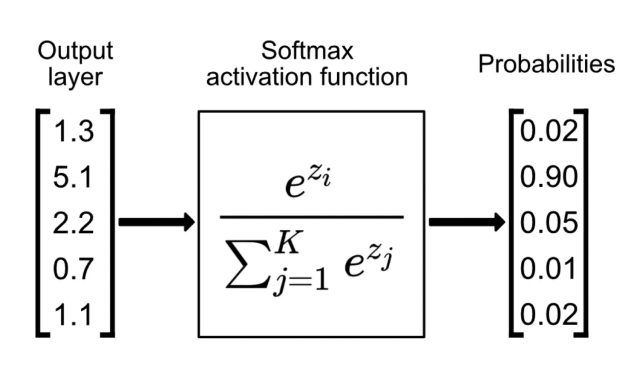

In [153]:
probs.shape

torch.Size([5, 27])

In [154]:
nlls = torch.zeros(5)
for i in range(5):
  # i-th bigram:
  x = xs[i].item() # input character index
  y = ys[i].item() # label character index
  print('--------')
  print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x},{y})')
  print('input to the neural net:', x)
  print('output probabilities from the neural net:', probs[i])
  print('label (actual next character):', y)
  p = probs[i, y]
  print('probability assigned by the net to the the correct character:', p.item())
  logp = torch.log(p)
  print('log likelihood:', logp.item())
  nll = -logp
  print('negative log likelihood:', nll.item())
  nlls[i] = nll

print('=========')
print('average negative log likelihood, i.e. loss =', nlls.mean().item())

--------
bigram example 1: .e (indexes 0,5)
input to the neural net: 0
output probabilities from the neural net: tensor([0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
        0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
        0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459])
label (actual next character): 5
probability assigned by the net to the the correct character: 0.012286250479519367
log likelihood: -4.3992743492126465
negative log likelihood: 4.3992743492126465
--------
bigram example 2: em (indexes 5,13)
input to the neural net: 5
output probabilities from the neural net: tensor([0.0290, 0.0796, 0.0248, 0.0521, 0.1989, 0.0289, 0.0094, 0.0335, 0.0097,
        0.0301, 0.0702, 0.0228, 0.0115, 0.0181, 0.0108, 0.0315, 0.0291, 0.0045,
        0.0916, 0.0215, 0.0486, 0.0300, 0.0501, 0.0027, 0.0118, 0.0022, 0.0472])
label (actual next character): 13
probability assigned by the net to the the correct character:

In [174]:
xs

tensor([ 0,  5, 13, 13,  1])

In [175]:
ys

tensor([ 5, 13, 13,  1,  0])

In [176]:
# randomly initialize 27 neurons' weights. each neuron receives 27 inputs
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

In [201]:
# forward pass
xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
logits = xenc @ W # predict log-counts
counts = logits.exp() # counts, equivalent to N
probs = counts / counts.sum(1, keepdims=True) # probabilities for next character

loss = -probs[torch.arange(5), ys].log().mean()


In [202]:
print(loss.item())

3.6493873596191406


In [199]:
# backward pass
W.grad = None # set to zero, None is more efficient
loss.backward()

In [200]:
W.data += -0.1 * W.grad

In [215]:
# put everything in loop
# create dataset
xs, ys = [], []
for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    xs.append(ix1)
    ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print('number of examples: ', num)

# initialize the 'network'
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

number of examples:  228146


In [213]:
# gradient descent
for k in range(100):
  
  # forward pass
  xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
  logits = xenc @ W # predict log-counts
  counts = logits.exp() # counts, equivalent to N
  probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
  loss = -probs[torch.arange(num), ys].log().mean()
  print(loss.item())
  
  # backward pass
  W.grad = None # set to zero the gradient
  loss.backward()
  
  # update
  W.data += -50 * W.grad

3.758953094482422
3.371100664138794
3.154043197631836
3.020373821258545
2.927711248397827
2.8604023456573486
2.8097290992736816
2.7701022624969482
2.7380731105804443
2.711496353149414
2.6890032291412354
2.6696884632110596
2.6529300212860107
2.638277292251587
2.6253879070281982
2.613990545272827
2.60386323928833
2.5948216915130615
2.5867116451263428
2.5794036388397217
2.572789192199707
2.5667762756347656
2.5612881183624268
2.5562589168548584
2.551633596420288
2.547366142272949
2.543415069580078
2.5397486686706543
2.5363364219665527
2.533154249191284
2.5301806926727295
2.5273969173431396
2.5247862339019775
2.522334575653076
2.520028829574585
2.517857789993286
2.515810489654541
2.513878345489502
2.512052059173584
2.510324001312256
2.5086867809295654
2.5071346759796143
2.5056614875793457
2.504261016845703
2.502929210662842
2.5016613006591797
2.5004520416259766
2.4992988109588623
2.498197317123413
2.4971446990966797
2.496137857437134
2.495173692703247
2.4942493438720703
2.493363380432129
2.

In [217]:
# gradient descent
for k in range(100):
  
  # forward pass
  xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
  logits = xenc @ W # predict log-counts
  counts = logits.exp() # counts, equivalent to N
  probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
  loss = -probs[torch.arange(num), ys].log().mean() + 0.01*(W**2).mean()
  print(loss.item())
  
  # backward pass
  W.grad = None # set to zero the gradient
  loss.backward()
  
  # update
  W.data += -50 * W.grad

3.76861834526062
3.3788065910339355
3.161090850830078
3.0271859169006348
2.9344840049743652
2.867231607437134
2.8166542053222656
2.777146339416504
2.7452542781829834
2.7188305854797363
2.696505546569824
2.6773719787597656
2.6608054637908936
2.6463515758514404
2.633664846420288
2.622471570968628
2.6125476360321045
2.6037068367004395
2.595794439315796
2.5886809825897217
2.5822560787200928
2.5764293670654297
2.5711236000061035
2.566272735595703
2.5618228912353516
2.5577263832092285
2.5539441108703613
2.550442695617676
2.5471930503845215
2.5441696643829346
2.5413525104522705
2.538722038269043
2.536262035369873
2.5339579582214355
2.5317976474761963
2.5297679901123047
2.527859926223755
2.5260636806488037
2.5243709087371826
2.522773027420044
2.52126407623291
2.519836664199829
2.5184855461120605
2.5172054767608643
2.515990734100342
2.5148372650146484
2.5137410163879395
2.51269793510437
2.511704921722412
2.5107579231262207
2.509855031967163
2.5089924335479736
2.5081682205200195
2.50738024711608

In [218]:
# finally, sample from the 'neural net' model
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
  
  out = []
  ix = 0
  while True:
    
    # ----------
    # BEFORE:
    #p = P[ix]
    # ----------
    # NOW:
    xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
    logits = xenc @ W # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    p = counts / counts.sum(1, keepdims=True) # probabilities for next character
    # ----------
    
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))

cexze.
momasurailezityha.
konimittain.
llayn.
ka.
